In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
from turborocket.profiling.Supersonic.transition import method_of_characteristics
from turborocket.profiling.Supersonic.circular import prandtl_meyer
from turborocket.profiling.Supersonic.supersonic_profile import SupersonicProfile

from turborocket.fluids.fluids import IdealGas

import numpy as np

import matplotlib.pyplot as plt


In [484]:
gamma = 1.4

v_i = prandtl_meyer(gamma, 1.5)
v_l = prandtl_meyer(gamma, 2.2)
k_max = 20

print(f"Prantdl Meyer Angles")
print(f"v_i: {v_i}")
print(f"v_l: {v_l}")

np.arange(start = 3, stop= k_max + 2, step=1)

np.linspace(3,1,3)


Prantdl Meyer Angles
v_i: 0.327233212037355
v_l: 1.2665826032604717


array([3., 2., 1.])

In [487]:
x, y = method_of_characteristics(k_max=k_max, v_i=v_i, v_l=v_l, gamma=gamma, alpha_l_i=0, reverse_x=True)

line = test.straight_zone(beta_m=-(v_i-v_l), initial_coord=(x[-1], y[-1]), x_f=-0.6 )

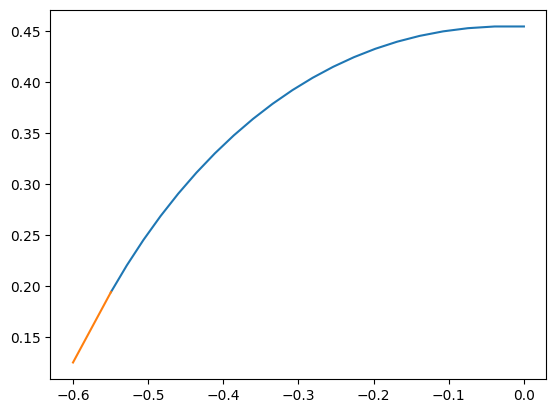

In [488]:
plt.plot(x, y)
plt.plot(line[:,0], line[:,1])

In [1259]:
gas = IdealGas(p=100e5, t=295, name="test", cp=1004, gamma=1.2)

In [ ]:
test = SupersonicProfile(beta=(-67, 67),
                         M_r=(1.59, 1.59),
                         M_s=(1.1, 1.8),
                         t_g_rat = 0.15,
                         g_expand = 0.2,
                         k_max=50,
                         fluid=gas)

Area Ratio: 1.0
Beta_i: -57
Beta_e: 50.15209735891582
Deflection: 10.0
alpha_l_i: 0.7976708744508056
alpha_u_i: 0.6463900914179428
target: 1.084373300367728
d_alpha: -0.08135326813886397
G_rat: 0.9409154165215255
1.084373300367728
1.084373300367728
Thickness: 0.25609415068320635
Radius: 0.05003197824797566
LE: 
[-1.19839738 -0.03574561]
[-1.10628802 -0.07484371]
TE: 
[1.54933433 0.05104582]
[ 1.43115847 -0.02770095]
Outlet Angle: -56.32239782790603
Wedge Angle: -0.24405980441659192


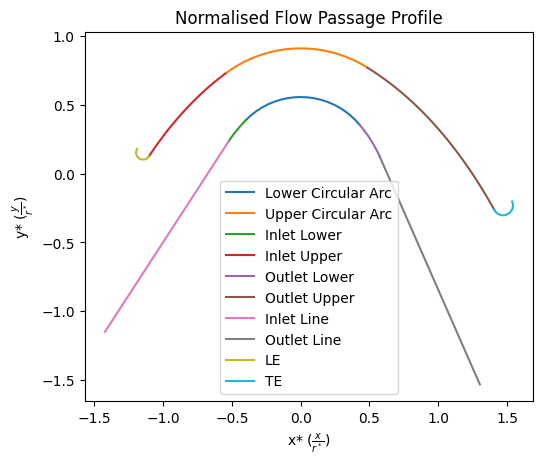

In [1658]:
test.plot_passage()

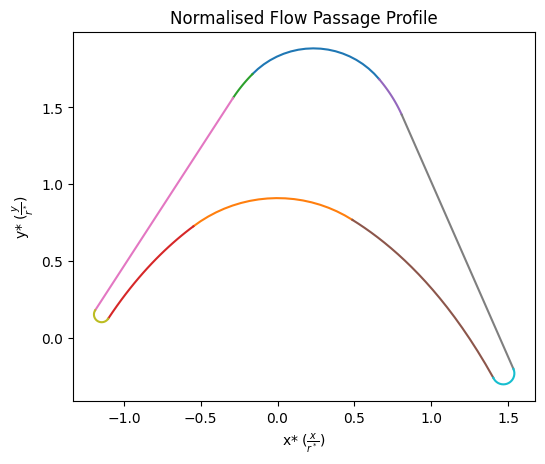

In [1659]:
test.plot_blade()

In [1708]:
df = test.generate_xy()

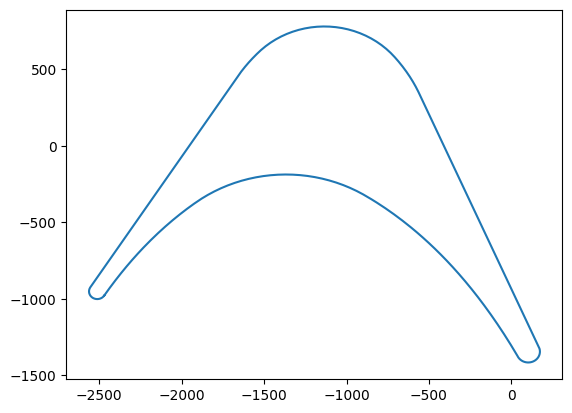

In [1709]:
plt.plot(df["x"], df["y"])
df.to_csv("blade.txt", sep="\t", index=False, header=False)